                       Open    High     Low   Close  Volume    Return
Datetime                                                             
2021-04-01 07:00:00  1.1724  1.1741  1.1712  1.1740   718.0  0.145014
2021-04-01 11:00:00  1.1741  1.1749  1.1723  1.1739   893.0 -0.008518
2021-04-01 15:00:00  1.1740  1.1773  1.1737  1.1771  1240.0  0.272596
2021-04-01 19:00:00  1.1770  1.1779  1.1765  1.1775   487.0  0.033982
2021-04-01 23:00:00  1.1774  1.1781  1.1770  1.1776   172.0  0.008493

Datos: 8367 velas (2021-2026)
STATISTICS:
 mean:  0.000
 std:  0.189
 skew:  0.291
 kurt:  10.639

PERCENTILES:
  p05: -0.284
  p25: -0.077
  p75: 0.078
  p95: 0.273

OUTLIERS:
  Total data points: 8367
  Outliers detected: 152
  Percentage: 1.82%

Plotting histogram...


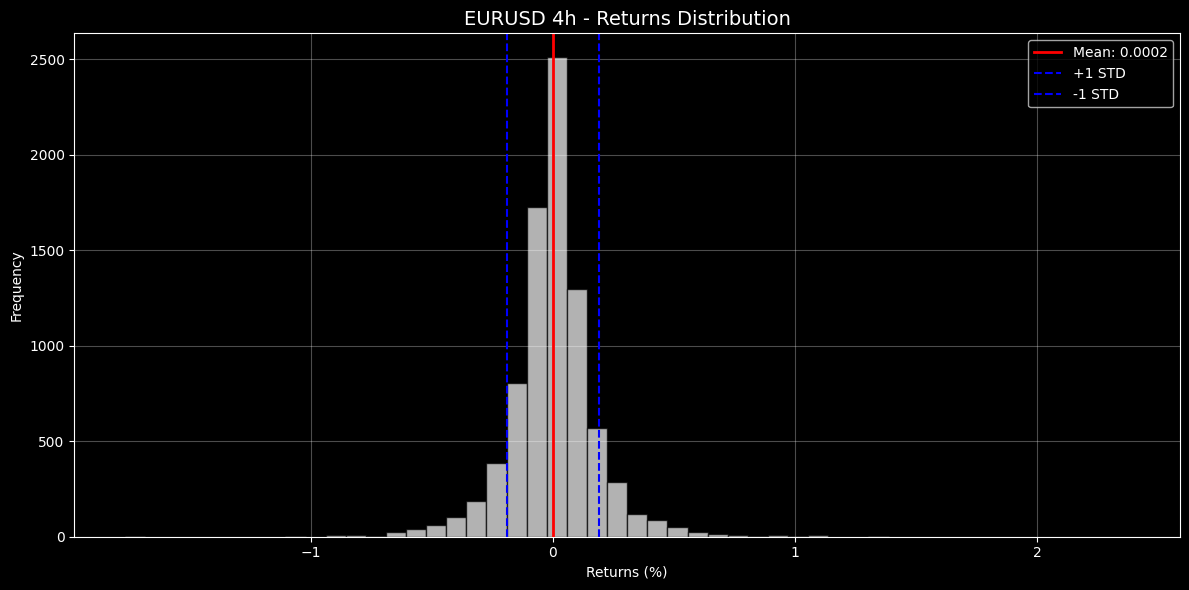

Plotting time series...


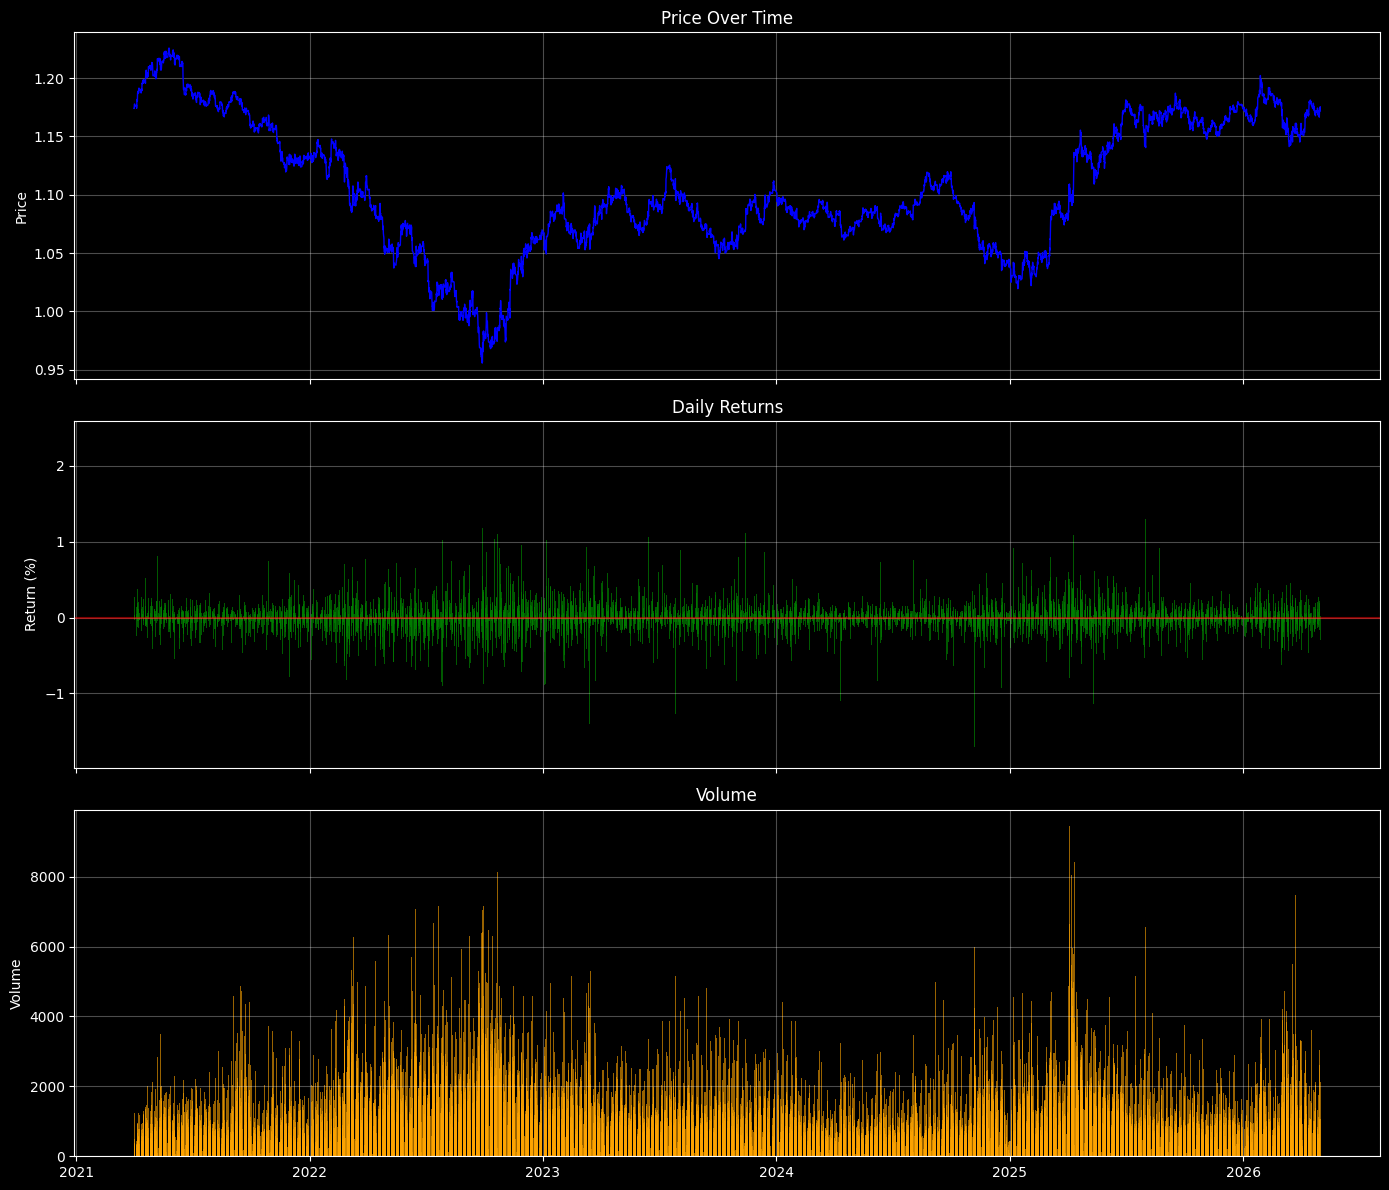

Plotting rolling statistics...


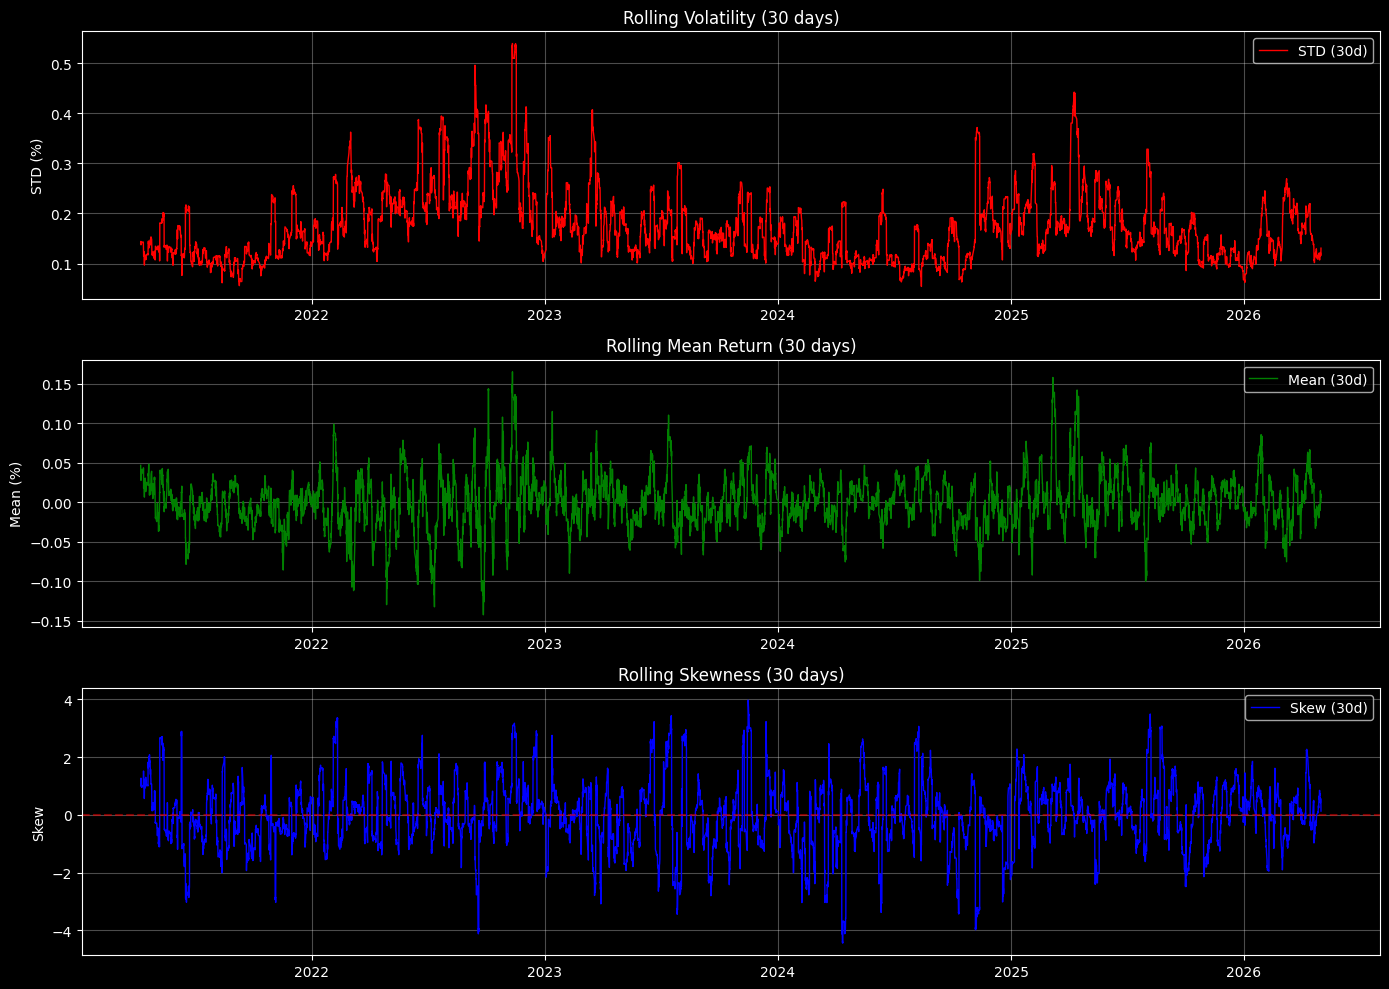

Plotting autocorrelation...


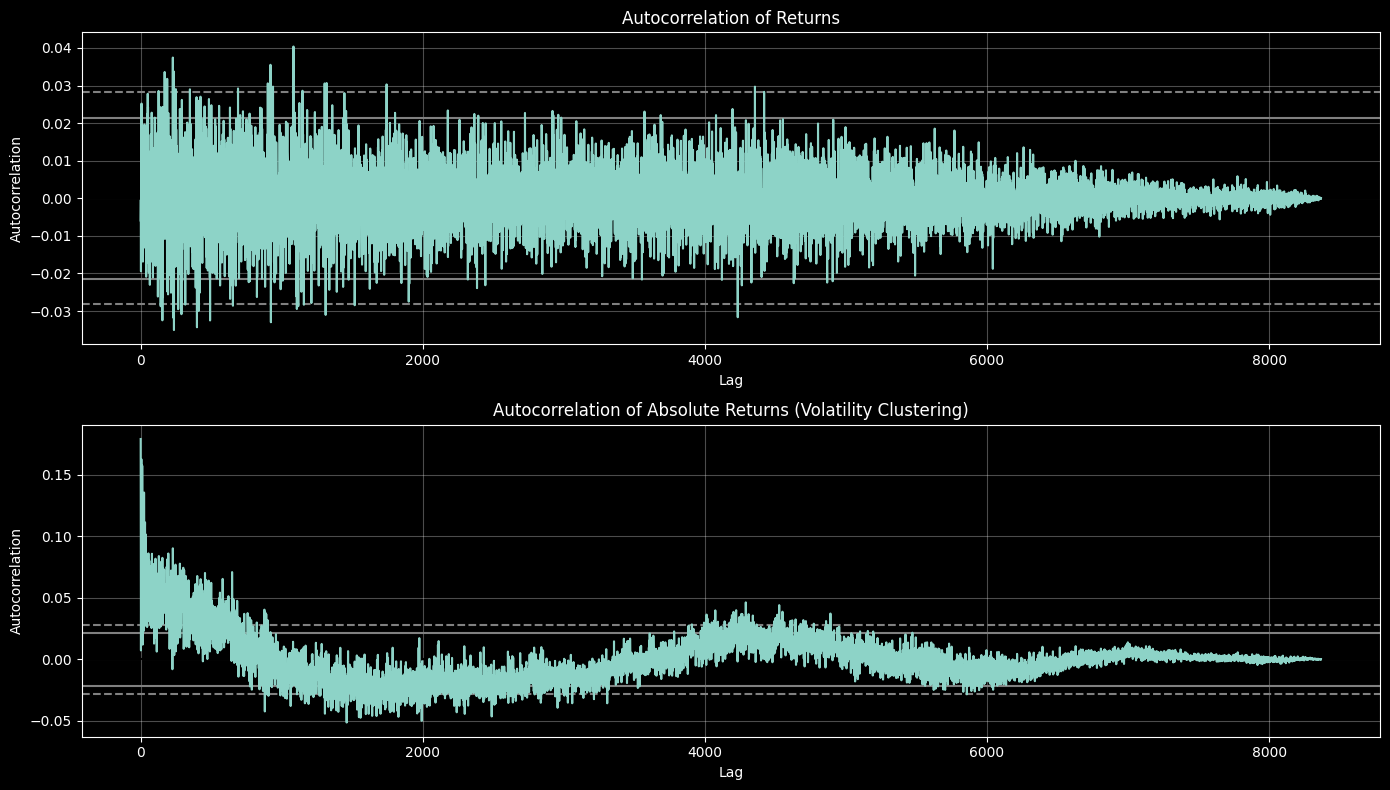


Outlier details (top 10):
                       Return  Distance (STD)
Datetime                                     
2021-05-07 15:00:00  0.812267        4.286349
2021-06-16 19:00:00 -0.932651        4.923606
2021-10-28 15:00:00  0.750259        3.959060
2021-10-29 15:00:00 -0.832904        4.397125
2021-11-30 14:00:00 -0.784348        4.140840
2021-11-30 18:00:00  0.586250        3.093394
2022-02-03 14:00:00  1.223513        6.456969
2022-02-11 18:00:00 -0.596439        3.149025
2022-02-24 02:00:00 -0.592711        3.129346
2022-02-24 10:00:00 -0.631448        3.333808



✅ Datos guardados en data/processed/


In [15]:
import sys
sys.path.append('/home/pulpo/Documents/quantitative-trading')
from src.quanttrading.data import prepare_data
from src.quanttrading.analysis import full_analysis
import pandas as pd

# TU CÓDIGO AQUÍ
df_eurusd = pd.read_csv('/home/pulpo/Documents/quantitative-trading/data/raw/EURUSD_4H_2021-04-01.csv', header=None)

# Renombrar columnas
df_eurusd.columns = ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']

# Combinar Date + Time
df_eurusd['Datetime'] = pd.to_datetime(df_eurusd['Date'] + ' ' + df_eurusd['Time'])

# Establecer índice
df_eurusd = df_eurusd.set_index('Datetime')

# Convertir a números
df_eurusd[['Open', 'High', 'Low', 'Close', 'Volume']] = df_eurusd[['Open', 'High', 'Low', 'Close', 'Volume']].astype(float)

# Calcular retornos
df_eurusd['Return'] = df_eurusd['Close'].pct_change() * 100

# Eliminar NaN
df_eurusd = df_eurusd.dropna()

# Eliminar columnas Date y Time
df_eurusd = df_eurusd[['Open', 'High', 'Low', 'Close', 'Volume', 'Return']]

print(df_eurusd.head())
print(f"\nDatos: {len(df_eurusd)} velas (2021-2026)")

# ANÁLISIS COMPLETO
results = full_analysis(df_eurusd, 'EURUSD 4h', window=30, threshold=3)

# Guardar para después
df_eurusd.to_csv('/home/pulpo/Documents/quantitative-trading/data/processed/EURUSD_2021_2026_cleaned.csv')
print("\n✅ Datos guardados en data/processed/")